Thomas Sears

9-20-26

Lab 4 - Two-Body Collisions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A - 1D Collisions with Restitution

Description : Simulates a 2 mass, collision system in 1-D by using a collide_1d function to calculate the final velocities of the 2 masses. Calculates the momentum and kinetic energy of the two masses using helper funcitions.

In [2]:
# 1-D collision simution
def collide_1d(m1, m2, u1, u2, e):

    total_m = m1 + m2

    # Center of Mass Velocity
    v_cm = (m1 * u1 + m2 * u2) / total_m

    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    return v1, v2


# Calculates total momentum and kinetic energy of the system
def total_momentum_1D(m1, u1, m2, u2):
    return m1*u1 + m2*u2

def total_ke_1D(m1, u1, m2, u2):
    return 0.5*m1*u1**2 + 0.5*m2*u2**2


# Verify the collide_1d function for e = 1
print("Verify collide 1-D function\n")
# Case 1 - Equal Masses (1 kg)
v_initial1 = 5.0
v_initial2 = 0.0
v_final1, v_final2 = collide_1d(1, 1, v_initial1, v_initial2, 1)
print("Mass 1 initial velocity (m/s): ", v_initial1)
print("Mass 1 final velocity (m/s:) ", v_final1)
print("Mass 2 initial velocity (m/s): ", v_initial2)
print("Mass 1 final velocity (m/s:) ", v_final2)

# Case 2 - Light Ball (0.1 kg) and stationary heavy ball (100 kg)
v_initial1 = 5.0
v_initial2 = 0.0
v_final1, v_final2 = collide_1d(0.1, 100, v_initial1, v_initial2, 1)
print("\nLight ball initial velocity (m/s): ", v_initial1)
print("Light ball final velocity (m/s:) ", round(v_final1, 2))
print("Heavy ball initial velocity (m/s): ", v_initial2)
print("Heavy ball final velocity (m/s:) ", round(v_final2, 2))

# Case 3 -  Stationary light ball (0.1 kg) and heavy ball (100 kg)
v_initial1 = 0.0
v_initial2 = 5.0
v_final1, v_final2 = collide_1d(0.1, 100, v_initial1, v_initial2, 1)
print("\nLight ball initial velocity (m/s): ", v_initial1)
print("Light ball final velocity (m/s:) ", round(v_final1, 2))
print("Heavy ball initial velocity (m/s): ", v_initial2)
print("Heavy ball final velocity (m/s:) ", round(v_final2, 2))

# Verify conservation of momentum and see what happens to kinetic energy as e decreases
m1 = 2.0
m2 = 3.0
u1 = 4.0
u2 = 0.0

# Calculate results for each coefficient of restitution
results = []

for e in [1.0, 0.5, 0.0]:

    # Initial momentum and kinetic energy
    p_before = total_momentum_1D(m1, u1, m2, u2)
    ke_before = total_ke_1D(m1, u1, m2, u2)

    # Final velocities
    v1, v2 = collide_1d(m1, m2, u1, u2, e)

    # Final momentum and kinetic energy
    p_after = total_momentum_1D(m1, v1, m2, v2)
    ke_after = total_ke_1D(m1, v1, m2, v2)

    results.append((e, v1, v2, p_before, p_after, ke_before, ke_after))

print("\nList containing set of v1, v2, p, ke values for each e value")
print(results)

Verify collide 1-D function

Mass 1 initial velocity (m/s):  5.0
Mass 1 final velocity (m/s:)  0.0
Mass 2 initial velocity (m/s):  0.0
Mass 1 final velocity (m/s:)  5.0

Light ball initial velocity (m/s):  5.0
Light ball final velocity (m/s:)  -4.99
Heavy ball initial velocity (m/s):  0.0
Heavy ball final velocity (m/s:)  0.01

Light ball initial velocity (m/s):  0.0
Light ball final velocity (m/s:)  9.99
Heavy ball initial velocity (m/s):  5.0
Heavy ball final velocity (m/s:)  4.99

List containing set of v1, v2, p, ke values for each e value
[(1.0, -0.7999999999999998, 3.2, 8.0, 8.000000000000002, 16.0, 16.000000000000004), (0.5, 0.40000000000000013, 2.4000000000000004, 8.0, 8.000000000000002, 16.0, 8.800000000000002), (0.0, 1.6, 1.6, 8.0, 8.0, 16.0, 6.400000000000001)]


## Conservation Table

| e | Momentum Before (kg m/s) | Momentum After (kg m/s) | KE Before (J) | KE After (J) |
|---:|---:|---:|---:|---:|
| 1.0 | 8.0 | 8.0 | 16.0 | 16.0 |
| 0.5 | 8.0 | 8.0 | 16.0 | 8.8 |
| 0.0 | 8.0 | 8.0 | 16.0 | 6.4 |

Discussion: As we can see, the momentum of the system is exactly 8.0 kg*m/s for all e, but kinetic energy decreases. The lost kinetic energy is in the form of heat energy, deformations, or some other type of energy transfer, it is not "lost" but converted into another form.

Part B - 2D Collisions in a Box

Description : Simulates a system of 2 balls with some mass in a box that can collide with each other and the boundary. This simulation uses a list called bodies which contains 2 dictionaries with information about each ball that gets updated with a time step dt using the Euler-Cromer Method.

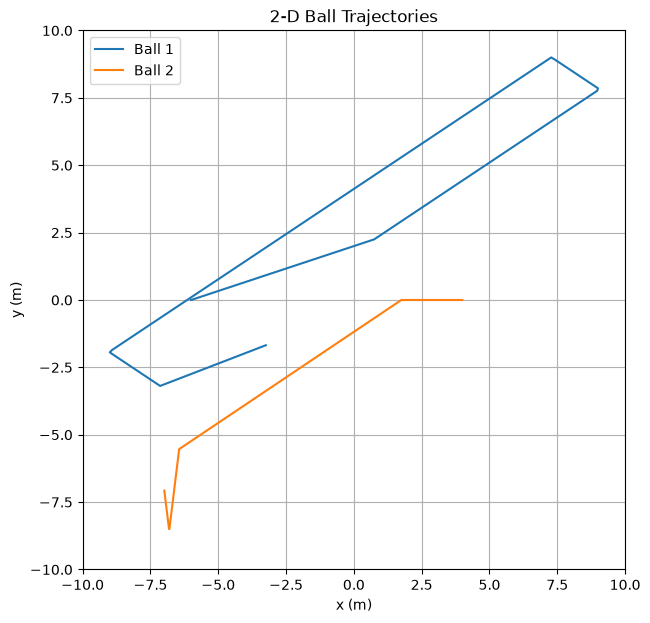

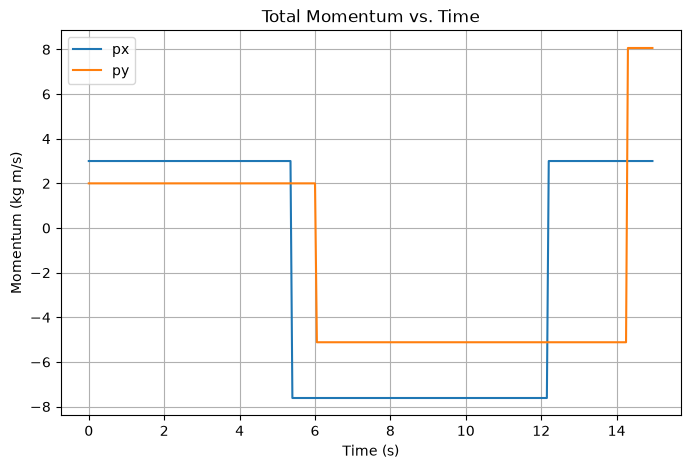

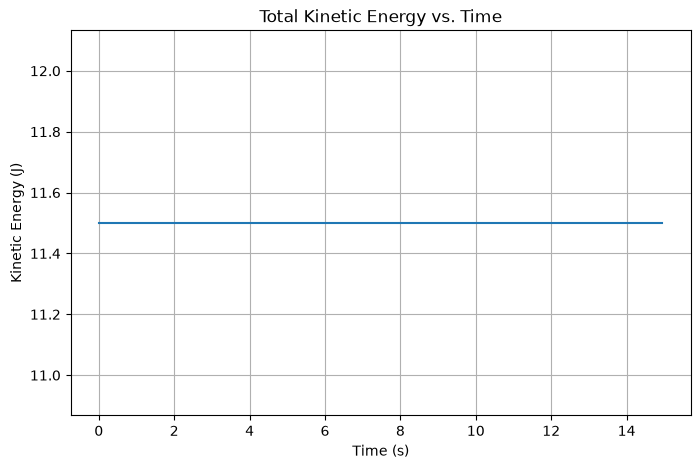

In [3]:
# Parameters
dt = 0.05
num_steps = 300
e = 1.0

# Boundaries
xmin = -10
xmax = 10
ymin = -10
ymax = 10

# Ball 1
ball1 = {
    "m": 2,
    "r": [-6, 0],
    "v": [3, 1],
    "radius": 1
}

# Ball 2
ball2 = {
    "m": 3,
    "r": [4, 0],
    "v": [-1, 0],
    "radius": 1.5
}

# List containing both bodies
bodies = [ball1, ball2]

# 2-D collision using line-of-centers decomposition
def collide_2d(body1, body2, e):

    r1 = np.array(body1["r"], dtype=float)
    r2 = np.array(body2["r"], dtype=float)

    v1 = np.array(body1["v"], dtype=float)
    v2 = np.array(body2["v"], dtype=float)

    # Unit vector
    n = r2 - r1
    n = n / np.linalg.norm(n)

    # Tangential unit vector
    t = np.array([-n[1], n[0]])

    # Normal velocity components
    u1_normal = np.dot(v1, n)
    u2_normal = np.dot(v2, n)

    # Tangential velocity components
    u1_tangent = np.dot(v1, t)
    u2_tangent = np.dot(v2, t)

    # Apply 1-D collision to normal components
    v1_normal, v2_normal = collide_1d(
        body1["m"], body2["m"],
        u1_normal, u2_normal,
        e
    )

    # 2-D velocities
    body1["v"] = list(v1_normal * n + u1_tangent * t)
    body2["v"] = list(v2_normal * n + u2_tangent * t)


# Total momentum of all bodies
def total_momentum(bodies):

    px = 0
    py = 0

    for body in bodies:
        px += body["m"] * body["v"][0]
        py += body["m"] * body["v"][1]

    return px, py


# Total kinetic energy of all bodies
def total_ke(bodies):

    ke = 0

    for body in bodies:
        vx = body["v"][0]
        vy = body["v"][1]

        ke += 0.5 * body["m"] * (vx**2 + vy**2)

    return ke


# Wall collision
def wall_collision(body, xmin, xmax, ymin, ymax):

    x, y = body["r"]
    vx, vy = body["v"]
    radius = body["radius"]

    # Left wall
    if x - radius < xmin:
        x = xmin + radius
        vx = -vx

    # Right wall
    if x + radius > xmax:
        x = xmax - radius
        vx = -vx

    # Bottom wall
    if y - radius < ymin:
        y = ymin + radius
        vy = -vy

    # Top wall
    if y + radius > ymax:
        y = ymax - radius
        vy = -vy

    body["r"] = [x, y]
    body["v"] = [vx, vy]


# Arrays for storing results
time = []
trajectory1 = []
trajectory2 = []
momentum_x = []
momentum_y = []
kinetic_energy = []


# Euler-Cromer Simulation
for step in range(num_steps):

    time.append(step * dt)

    trajectory1.append(bodies[0]["r"].copy())
    trajectory2.append(bodies[1]["r"].copy())

    px, py = total_momentum(bodies)
    momentum_x.append(px)
    momentum_y.append(py)

    kinetic_energy.append(total_ke(bodies))

    for body in bodies:
        body["r"][0] += body["v"][0] * dt
        body["r"][1] += body["v"][1] * dt


    # Check wall collisions
    for body in bodies:
        wall_collision(body, xmin, xmax, ymin, ymax)


    # Check collision
    r1 = np.array(bodies[0]["r"])
    r2 = np.array(bodies[1]["r"])

    v1 = np.array(bodies[0]["v"])
    v2 = np.array(bodies[1]["v"])

    distance = np.linalg.norm(r2 - r1)

    collision_distance = (
        bodies[0]["radius"] + bodies[1]["radius"]
    )

    # Unit vector from mass 1 to mass 2
    n = (r2 - r1) / distance

    # Relative velocity along line of centers
    relative_velocity = np.dot(v2 - v1, n)

    # Resolve if overlapping and approaching
    if distance < collision_distance and relative_velocity < 0:
        collide_2d(bodies[0], bodies[1], e)


trajectory1 = np.array(trajectory1)
trajectory2 = np.array(trajectory2)

# Trajectory plot
plt.figure(figsize=(7, 7))

plt.plot(
    trajectory1[:, 0],
    trajectory1[:, 1],
    label="Ball 1"
)

plt.plot(
    trajectory2[:, 0],
    trajectory2[:, 1],
    label="Ball 2"
)

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("2-D Ball Trajectories")
plt.legend()
plt.grid()

plt.show()

# Momentum plot
plt.figure(figsize=(8, 5))

plt.plot(time, momentum_x, label="px")
plt.plot(time, momentum_y, label="py")

plt.xlabel("Time (s)")
plt.ylabel("Momentum (kg m/s)")
plt.title("Total Momentum vs. Time")
plt.legend()
plt.grid()

plt.show()

# Kinetic energy plot
plt.figure(figsize=(8, 5))

plt.plot(time, kinetic_energy)

plt.xlabel("Time (s)")
plt.ylabel("Kinetic Energy (J)")
plt.title("Total Kinetic Energy vs. Time")
plt.grid()

plt.show()

Discussion: The graph of kinetic energy for a perfectly elastic collision between the 2 balls should be constant with time. This is exactly what my simulation shows as the kinetic energy is constant. Kinetic energy is constant because e = 1 meaning there is not energy lost to heat, deformation, or some other source. My momentum graph looks like a piece-wise function with sudden jumps. This is the expected result because when a ball interacts with the wall, it provides and impluse which instantenously changes the momentum in either the x or y direction depending on which wall is hit.

Part C - Inelastic Collisions & Energy Accounting

Description : This section incorporates parameterization and energy tracking as a means of verifying the simulation. For a given set of e values, this code calculates the total energy of the system at a given time step and e value and then finds when the kinetic energy decreases in order to check if this is a valid way to model this system.

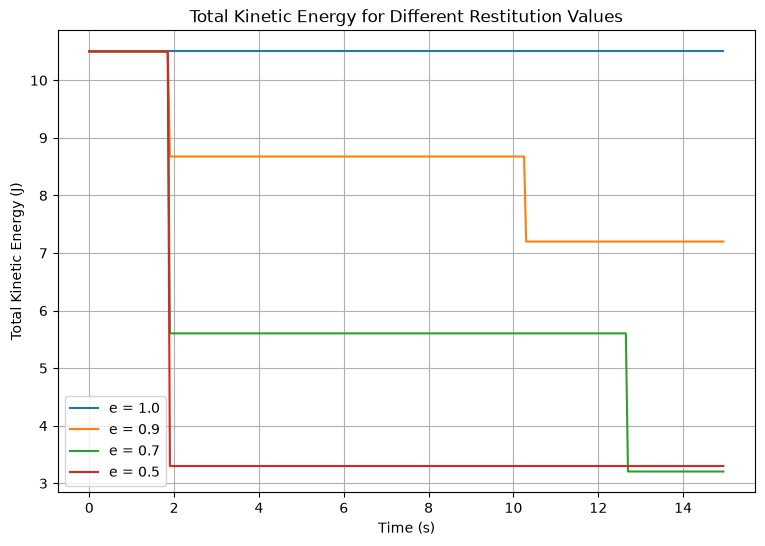

Fraction of KE lost in first ball-ball collision

e = 1.0
Initial KE (J):  10.5
KE after impact (J):  10.5
Fraction lost :  0.0
Theory :  0.0
e = 0.9
Initial KE (J):  10.5
KE after impact (J):  8.676
Fraction lost :  0.174
Theory :  0.174
e = 0.7
Initial KE (J):  10.5
KE after impact (J):  5.604
Fraction lost :  0.466
Theory :  0.466
e = 0.5
Initial KE (J):  10.5
KE after impact (J):  3.3
Fraction lost :  0.686
Theory :  0.686


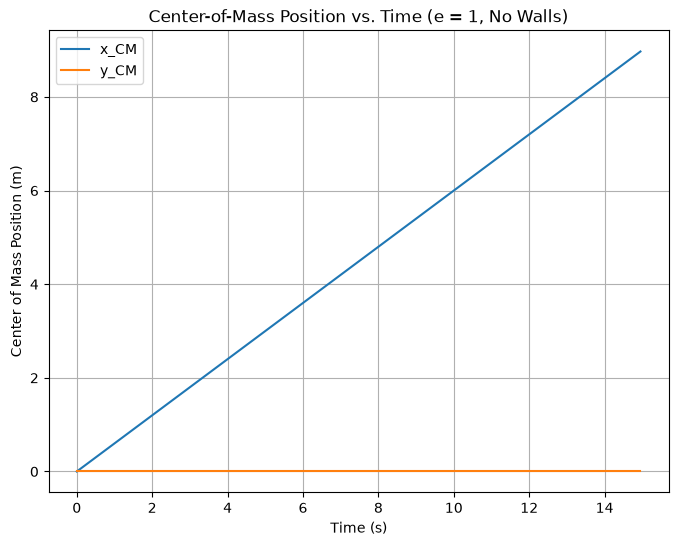

In [ ]:
# Parameters
dt = 0.05
num_steps = 300

# Values of the coefficient of restitution
e_values = [1.0, 0.9, 0.7, 0.5]

# Boundaries
xmin = -10
xmax = 10
ymin = -10
ymax = 10


# Ball 1
ball1 = {
    "m": 2,
    "r": [-6, 0],
    "v": [3, 0],
    "radius": 1
}

# Ball 2
ball2 = {
    "m": 3,
    "r": [4, 0],
    "v": [-1, 0],
    "radius": 1.5
}

# List containing both bodies
bodies = [ball1, ball2]

# Function to reset the bodies
def reset_bodies():

    return [
        {
            "m": body["m"],
            "r": body["r"].copy(),
            "v": body["v"].copy(),
            "radius": body["radius"]
        }
        for body in bodies
    ]


# Simulation
def run_simulation(e, use_walls = True):

    simulation_bodies = reset_bodies()

    time = []
    kinetic_energy = []
    com_positions = []

    for step in range(num_steps):

        time.append(step * dt)

        # Store total kinetic energy
        kinetic_energy.append(total_ke(simulation_bodies))

        # Calculate center of mass
        total_mass = sum(body["m"] for body in simulation_bodies)

        com_x = sum(body["m"] * body["r"][0] for body in simulation_bodies) / total_mass

        com_y = sum(body["m"] * body["r"][1] for body in simulation_bodies) / total_mass

        com_positions.append([com_x, com_y])


        # Euler-Cromer update
        for body in simulation_bodies:
            body["r"][0] += body["v"][0] * dt
            body["r"][1] += body["v"][1] * dt


        # Check wall collisions
        if use_walls:
            for body in simulation_bodies:
                wall_collision(body, xmin, xmax, ymin, ymax)



        # Check ball collision
        r1 = np.array(simulation_bodies[0]["r"])
        r2 = np.array(simulation_bodies[1]["r"])

        v1 = np.array(simulation_bodies[0]["v"])
        v2 = np.array(simulation_bodies[1]["v"])

        distance = np.linalg.norm(r2 - r1)

        collision_distance = (simulation_bodies[0]["radius"] + simulation_bodies[1]["radius"])

        # Unit vector from ball 1 to ball 2
        if distance > 0:

            n = (r2 - r1) / distance

            # Velocity along line of centers
            relative_velocity = np.dot(v2 - v1, n)

            # Only collide if overlapping AND approaching
            if (distance < collision_distance and relative_velocity < 0):
                collide_2d(simulation_bodies[0], simulation_bodies[1], e)

    return (np.array(time), np.array(kinetic_energy), np.array(com_positions))

# Restitution sweep
results = {}

for e in e_values:

    time, ke, com = run_simulation(e)

    results[e] = {
        "time": time,
        "ke": ke,
        "com": com
    }

# Plot total KE
plt.figure(figsize=(9, 6))

for e in e_values:
    plt.plot(results[e]["time"], results[e]["ke"], label=f"e = {e}")

plt.xlabel("Time (s)")
plt.ylabel("Total Kinetic Energy (J)")
plt.title("Total Kinetic Energy for Different Restitution Values")
plt.legend()
plt.grid()

plt.show()

# Calculate fraction of KE lost
print("Fraction of KE lost in first ball-ball collision")
print()

# Initial total kinetic energy
initial_ke = total_ke(bodies)

m1 = bodies[0]["m"]
m2 = bodies[1]["m"]

# Initial velocities
v1_initial = np.array(bodies[0]["v"], dtype=float)
v2_initial = np.array(bodies[1]["v"], dtype=float)

# Relative velocity
v_relative = v1_initial - v2_initial

# Center-of-mass velocity
v_cm = (m1 * v1_initial + m2 * v2_initial) / (m1 + m2)

# Reduced mass
mu = (m1 * m2) / (m1 + m2)

# Kinetic energy associated with relative motion
relative_ke = 0.5 * mu * np.dot(v_relative, v_relative)

for e in e_values:

    time, ke, com = run_simulation(e)

    # Find first decrease in kinetic energy
    collision_ke = initial_ke

    for i in range(1, len(ke)):
        if ke[i] < ke[i - 1]:
            collision_ke = ke[i]
            break

    # Fraction of total KE lost in simulation
    fraction_lost = ((initial_ke - collision_ke) / initial_ke)

    # Theoretical fraction of TOTAL KE lost
    theoretical_loss = (relative_ke / initial_ke) * (1 - e**2)
    
    print(f"e = {e}")
    print("Initial KE (J): ", round(initial_ke, 3))
    print("KE after impact (J): ", round(collision_ke, 3))
    print("Fraction lost : ", round(fraction_lost, 3))
    print("Theory : ", round(theoretical_loss, 3))

# Center-of-mass test
time_com, ke_com, com_positions = run_simulation(e = 1.0, use_walls = False)

plt.figure(figsize=(8, 6))

plt.plot(time_com, com_positions[:, 0], label="x_CM")
plt.plot(time_com, com_positions[:, 1], label="y_CM")

plt.xlabel("Time (s)")
plt.ylabel("Center of Mass Position (m)")
plt.title("Center-of-Mass Position vs. Time (e = 1, No Walls)")
plt.legend()
plt.grid()

plt.show()

Discussion : The total kinetic energy of the system does not increase for any value of e. This is what is expected from the theory. If the kinetic energy did increase for any time step, it would mean the simulation is incorrectly calculating kinetic energy because it is physically impossible for kinetic energy to be added to the system because e = 1 means conservation of kinetic energy while e < 1 means atleast some kinetic energy will be lost. This is why a kinetic energy tracking method is so valuable for a simulation like this, it will tell you if the simulation is behaving as intended or if there is some issue with it. Even without an exact solution, kinetic energy increasing is not possible so, it confirms if your simulation is correct.